# Factors Associated with Poor Self-Rated Health

## Research Question

Which demographic, socioeconomic, lifestyle, and physical factors are most strongly associated with poor self-rated health?

This project analyzes health survey data using exploratory data analysis and machine learning. Self-rated health was converted into a binary outcome:

- **0 — Good or Better:** Excellent, Very good, or Good
- **1 — Fair or Poor:** Fair or Poor

The analysis examines the predictive contribution of six factors:

- Age
- Education
- Income/Poverty
- BMI category
- Smoking status
- Physical activity

## 1. Data Loading and Initial Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/17322/OneDrive/Desktop/EDA/data/adult24.csv")

df.shape

(32629, 630)

In [2]:
# Which demographic, socioeconomic, lifestyle, and physical factors are most strongly associated with poor self-rated health?

In [3]:
df.head()

,RATCAT_A,INCTCFLG_A,IMPINCFLG_A,PPSU,PSTRAT,WLKLEISTC_A,WLKTRANTC_A,HISPALLP_A,RACEALLP_A,ANYDIFF_A,...,LSATIS4_A,PHSTAT_A,HHSTAT_A,INTV_MON,RECTYPE,IMPNUM_A,AVGNUMCIG_A,WTFA_A,HHX,POVRATTC_A
0,9,0,2,2,122,NaN,NaN,2,1,2,...,1,1,1,1,10,1,30,5780.565,H067658,2.82
1,8,0,0,2,122,20.0,NaN,2,1,2,...,2,2,1,1,10,1,20,3994.244,H076577,2.01
2,7,0,0,2,122,30.0,NaN,2,1,1,...,1,2,1,1,10,1,20,6636.755,H019335,1.90
3,12,0,0,2,122,10.0,NaN,2,1,1,...,2,3,1,1,10,1,01,13767.420,H012701,4.48
4,14,0,0,1,115,NaN,NaN,3,2,1,...,2,3,1,1,10,1,NaN,18880.030,H049678,6.37


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32629 entries, 0 to 32628
Columns: 630 entries, RATCAT_A to POVRATTC_A
dtypes: float64(401), int64(227), str(2)
memory usage: 156.8 MB


## 2. Data Cleaning and Feature Selection

The original dataset contained a large number of health survey variables. For this analysis, variables relevant to the research question were selected and cleaned.

The predictors represent demographic, socioeconomic, lifestyle, and physical characteristics.

In [5]:
df.isnull().sum().sort_values(ascending=False).head(20)

CHFLG_A         32629
PRPLCOV2_C_A    32628
OGFLG_A         32628
OPFLG_A         32628
CHHDHP_A        32628
CHXCHNG_A       32626
CHDEDUC_A       32626
CHPREM_A        32626
LARYNAGETC_A    32626
GALLBAGETC_A    32623
MOUTHAGETC_A    32617
PANCRAGETC_A    32610
ESOPHAGETC_A    32609
OGHDHP_A        32606
INJFALLWRK_A    32605
STOMAAGETC_A    32604
PRPLCOV1_C_A    32603
DIBINSSTYR_A    32603
RECTUAGETC_A    32602
BRAINAGETC_A    32602
dtype: int64

In [6]:
# Which of these columns might be relevant to our research question?

In [7]:
df.columns.tolist()

['RATCAT_A',
 'INCTCFLG_A',
 'IMPINCFLG_A',
 'PPSU',
 'PSTRAT',
 'WLKLEISTC_A',
 'WLKTRANTC_A',
 'HISPALLP_A',
 'RACEALLP_A',
 'ANYDIFF_A',
 'DISAB3_A',
 'NUMBRN1TC_A',
 'K6SPD_A',
 'SCHDYMSSTC_A',
 'AFNOW',
 'REPWRKDYTC_A',
 'YRSINUS_A',
 'CITZNSTP_A',
 'PRTNREDUCP_A',
 'SPOUSEDUCP_A',
 'LEGMSTAT_A',
 'MARSTAT_A',
 'SASPPRACE_A',
 'SASPPHISP_A',
 'PRTNRAGETC_A',
 'SPOUSAGETC_A',
 'PRTNRWKFT_A',
 'PRTNRWRK_A',
 'SPOUSWKFT_A',
 'SPOUSWRK_A',
 'SPOUSESEX_A',
 'PRTNRSEX_A',
 'INJWRKDYTC_A',
 'NUMINJTC_A',
 'SHINGYEARP_A',
 'PROXYREL2_A',
 'PROXYFLAG_A',
 'HHRESPSA_FLG',
 'PCNTADWFP1_A',
 'PCNTADWKP1_A',
 'FDSCAT4_A',
 'FDSCAT3_A',
 'EMPDYSMSS3_A',
 'EMPLSTWOR1_A',
 'EMPWRKFT1_A',
 'EMPWRKLSW1_A',
 'EMPWKHRS3_A',
 'EMDOCCUPN2_A',
 'EMDOCCUPN1_A',
 'EMDINDSTN2_A',
 'EMDINDSTN1_A',
 'DIBAGETC_A',
 'DIFYRSTC1_A',
 'SMKQTNP_A',
 'SMKQTY_A',
 'SMKECIGST_A',
 'SMKCIGST_A',
 'BMICATD_A',
 'BMICAT_A',
 'WEIGHTLBTC_A',
 'HEIGHTTC_A',
 'DRKHVY12M_A',
 'DRKSTAT_A',
 'DRK12MYR_A',
 'DRK12MWK_A',
 'RET

In [8]:
[col for col in df.columns if "AGE" in col]

['PRTNRAGETC_A',
 'SPOUSAGETC_A',
 'DIBAGETC_A',
 'COLRCAGETC_A',
 'HDNCKAGETC_A',
 'OTHERAGETC_A',
 'UTERUAGETC_A',
 'THYROAGETC_A',
 'THROAAGETC_A',
 'STOMAAGETC_A',
 'SKNDKAGETC_A',
 'SKNNMAGETC_A',
 'SKNMAGETC_A',
 'RECTUAGETC_A',
 'PROSTAGETC_A',
 'PANCRAGETC_A',
 'OVARYAGETC_A',
 'MOUTHAGETC_A',
 'MELANAGETC_A',
 'LYMPHAGETC_A',
 'LUNGAGETC_A',
 'LIVERAGETC_A',
 'LEUKEAGETC_A',
 'LARYNAGETC_A',
 'GALLBAGETC_A',
 'ESOPHAGETC_A',
 'COLONAGETC_A',
 'CERVIAGETC_A',
 'BREASAGETC_A',
 'BRAINAGETC_A',
 'BONEAGETC_A',
 'BLOODAGETC_A',
 'BLADDAGETC_A',
 'AGEP_A',
 'AGE65',
 'SMKAGE_A',
 'HISTOPAGE_A']

In [9]:
[col for col in df.columns if "HEALTH" in col]

['WORKHEALTH_A']

In [10]:
[col for col in df.columns if "BMI" in col]

['BMICATD_A', 'BMICAT_A']

In [11]:
[col for col in df.columns if "SLEEP" in col]

[]

In [12]:
[col for col in df.columns if "INCOME" in col]

[]

In [13]:
[col for col in df.columns if "EDU" in col]

['PRTNREDUCP_A',
 'SPOUSEDUCP_A',
 'EDUCP_A',
 'MAXEDUCP_A',
 'INJREDUCE_A',
 'REPREDUCE_A',
 'OGDEDUC_A',
 'OPDEDUC_A',
 'CHDEDUC_A',
 'PRDEDUC2_A',
 'PRDEDUC1_A',
 'MADEDUC_A']

In [14]:
[col for col in df.columns if "PHYS" in col]

[]

## 3. Exploratory Data Analysis

In [15]:
selected_columns = ["PHSTAT_A", 
                    "AGEP_A",
                    "SEX_A",
                    "HISPALLP_A",
                    "EDUCP_A",
                    "RATCAT_A",
                    "BMICATD_A",
                    "SMKCIGST_A",
                    "PA18_05R_A"]

df_eda = df[selected_columns].copy()

In [16]:
df_eda.shape

(32629, 9)

In [17]:
df_eda.head()

,PHSTAT_A,AGEP_A,SEX_A,HISPALLP_A,EDUCP_A,RATCAT_A,BMICATD_A,SMKCIGST_A,PA18_05R_A
0,1,49,1,2,5,9,3,3,3
1,2,53,1,2,5,8,3,3,1
2,2,82,1,2,5,7,4,3,1
3,3,42,1,2,4,12,3,3,1
4,3,38,2,3,9,14,3,4,4


In [18]:
df_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 32629 entries, 0 to 32628
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   PHSTAT_A    32629 non-null  int64
 1   AGEP_A      32629 non-null  int64
 2   SEX_A       32629 non-null  int64
 3   HISPALLP_A  32629 non-null  int64
 4   EDUCP_A     32629 non-null  int64
 5   RATCAT_A    32629 non-null  int64
 6   BMICATD_A   32629 non-null  int64
 7   SMKCIGST_A  32629 non-null  int64
 8   PA18_05R_A  32629 non-null  int64
dtypes: int64(9)
memory usage: 2.2 MB


In [19]:
df_eda.columns

Index(['PHSTAT_A', 'AGEP_A', 'SEX_A', 'HISPALLP_A', 'EDUCP_A', 'RATCAT_A',
       'BMICATD_A', 'SMKCIGST_A', 'PA18_05R_A'],
      dtype='str')

In [20]:
df_eda["PHSTAT_A"].value_counts().sort_index()

PHSTAT_A
1     6302
2    10919
3    10037
4     4147
5     1208
7        9
9        7
Name: count, dtype: int64

In [21]:
health_map = {
    1: "Excellent", 
    2: "Very good",
    3: "Good", 
    4: "Fair",
    5: "Poor"
}

df_eda["general_health"] = df_eda["PHSTAT_A"].map(health_map)

In [22]:
df_eda["general_health"].value_counts()

general_health
Very good    10919
Good         10037
Excellent     6302
Fair          4147
Poor          1208
Name: count, dtype: int64

In [23]:
df_eda["SEX_A"].value_counts().sort_index()

SEX_A
1    14985
2    17639
7        3
9        2
Name: count, dtype: int64

In [24]:
sex_map = {
    1: "Male", 
    2: "Female"
}

df_eda["sex"] = df_eda["SEX_A"].map(sex_map)

In [25]:
df_eda["sex"].value_counts()

sex
Female    17639
Male      14985
Name: count, dtype: int64

In [26]:
age_bins = [18, 25, 35, 45, 55, 65, 200]

age_labels = [
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

df_eda["age_group"] = pd.cut(
    df_eda["AGEP_A"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

In [27]:
df_eda["age_group"].value_counts().sort_index()

age_group
18-24     2008
25-34     4676
35-44     5057
45-54     4446
55-64     5467
65+      10975
Name: count, dtype: int64

In [28]:
race_map = {
    1: "Hispanic",
    2: "Non-Hispanic White",
    3: "Non-Hispanic Black",
    4: "Non-Hispanic Asian",
    5: "Non-Hispanic Other"
}

df_eda["race_ethnicity"] = df_eda["HISPALLP_A"].map(race_map)

In [29]:
df_eda["race_ethnicity"].value_counts()

race_ethnicity
Non-Hispanic White    21770
Hispanic               4762
Non-Hispanic Black     3296
Non-Hispanic Asian     1869
Non-Hispanic Other      268
Name: count, dtype: int64

In [30]:
education_map = {
    1: "Less than high school",
    2: "High school graduate",
    3: "Some college",
    4: "Associate degree",
    5: "Bachelor's degree",
    6: "Graduate degree"
}

df_eda["education"] = df_eda["EDUCP_A"].map(education_map)

In [31]:
df_eda["education"].value_counts().sort_index()

education
Associate degree         7605
Bachelor's degree        4698
Graduate degree          1335
High school graduate      534
Less than high school    2131
Some college              803
Name: count, dtype: int64

In [32]:
df_eda["RATCAT_A"].value_counts().sort_index()

RATCAT_A
1      936
2      882
3     1607
4     1252
5     1660
6     1443
7     1434
8     2837
9     2689
10    2341
11    1900
12    2041
13    1645
14    9962
Name: count, dtype: int64

In [33]:
df["BMICATD_A"] = df["BMICATD_A"].replace(9, np.nan)

In [34]:
df_eda["BMICATD_A"].value_counts().sort_index()

BMICATD_A
1      554
2     9996
3    10791
4     6365
5     2556
6     1767
9      600
Name: count, dtype: int64

In [35]:
bmi_map = {
    1: "Underweight",
    2: "Healthy weight",
    3: "Overweight",
    4: "Class 1 obesity",
    5: "Class 2 obesity",
    6: "Class 3 obesity"
}

df["bmi_category"] = df["BMICATD_A"].map(bmi_map)

C:\Users\17322\AppData\Local\Temp\ipykernel_10136\158604812.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["bmi_category"] = df["BMICATD_A"].map(bmi_map)


In [36]:
df_eda["SMKCIGST_A"].value_counts().sort_index()

SMKCIGST_A
1     2513
2      850
3     8162
4    20351
5       16
9      737
Name: count, dtype: int64

In [37]:
df["smoking_status"] = df["SMKCIGST_A"].map({
    1: "Current smoker",
    2: "Current smoker",
    3: "Former smoker",
    4: "Never smoker"
})

C:\Users\17322\AppData\Local\Temp\ipykernel_10136\1243937876.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["smoking_status"] = df["SMKCIGST_A"].map({


In [38]:
df["smoking_status"].value_counts().sort_index()

smoking_status
Current smoker     3363
Former smoker      8162
Never smoker      20351
Name: count, dtype: int64

In [39]:
df_eda["PA18_05R_A"].value_counts().sort_index()

PA18_05R_A
1    14554
2     2097
3     7045
4     7650
8     1283
Name: count, dtype: int64

In [40]:
df["physical_activity"] = df["PA18_05R_A"].map({
    1: "Neither", 
    2: "Strengthening only",
    3: "Aerobic only",
    4: "Both"
})

C:\Users\17322\AppData\Local\Temp\ipykernel_10136\3672365303.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["physical_activity"] = df["PA18_05R_A"].map({


In [41]:
# Education
education_map = {
    1: "Less than high school",
    2: "Less than high school",
    3: "Less than high school",
    4: "High school graduate",
    5: "Some college",
    6: "Associate's degree",
    7: "Associate's degree",
    8: "Bachelor's degree",
    9: "Graduate degree",
    10: "Graduate degree"
}

df["education"] = df["EDUCP_A"].map(education_map)


# Income to poverty ratio
income_map = {
    1: "0.00–0.49",
    2: "0.50–0.74",
    3: "0.75–0.99",
    4: "1.00–1.24",
    5: "1.25–1.49",
    6: "1.50–1.74",
    7: "1.75–1.99",
    8: "2.00–2.49",
    9: "2.50–2.99",
    10: "3.00–3.49",
    11: "3.50–3.99",
    12: "4.00–4.49",
    13: "4.50–4.99",
    14: "5.00+"
}

df["income_poverty"] = df["RATCAT_A"].map(income_map)


# BMI
bmi_map = {
    1: "Underweight",
    2: "Healthy weight",
    3: "Overweight",
    4: "Class 1 obesity",
    5: "Class 2 obesity",
    6: "Class 3 obesity"
}

df["bmi_category"] = df["BMICATD_A"].map(bmi_map)


# Smoking
smoking_map = {
    1: "Current smoker",
    2: "Current smoker",
    3: "Former smoker",
    4: "Never smoker"
}

df["smoking_status"] = df["SMKCIGST_A"].map(smoking_map)


# Physical activity
activity_map = {
    1: "Neither",
    2: "Strengthening only",
    3: "Aerobic only",
    4: "Both"
}

df["physical_activity"] = df["PA18_05R_A"].map(activity_map)

C:\Users\17322\AppData\Local\Temp\ipykernel_10136\2611408534.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["education"] = df["EDUCP_A"].map(education_map)
C:\Users\17322\AppData\Local\Temp\ipykernel_10136\2611408534.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["income_poverty"] = df["RATCAT_A"].map(income_map)


In [42]:
print(df["education"].value_counts())
print()
print(df["income_poverty"].value_counts())
print()
print(df["bmi_category"].value_counts())
print()
print(df["smoking_status"].value_counts())
print()
print(df["physical_activity"].value_counts())

education
High school graduate     7605
Bachelor's degree        7482
Graduate degree          4877
Some college             4698
Associate's degree       4352
Less than high school    3468
Name: count, dtype: int64

income_poverty
5.00+        9962
2.00–2.49    2837
2.50–2.99    2689
3.00–3.49    2341
4.00–4.49    2041
3.50–3.99    1900
1.25–1.49    1660
4.50–4.99    1645
0.75–0.99    1607
1.50–1.74    1443
1.75–1.99    1434
1.00–1.24    1252
0.00–0.49     936
0.50–0.74     882
Name: count, dtype: int64

bmi_category
Overweight         10791
Healthy weight      9996
Class 1 obesity     6365
Class 2 obesity     2556
Class 3 obesity     1767
Underweight          554
Name: count, dtype: int64

smoking_status
Never smoker      20351
Former smoker      8162
Current smoker     3363
Name: count, dtype: int64

physical_activity
Neither               14554
Both                   7650
Aerobic only           7045
Strengthening only     2097
Name: count, dtype: int64


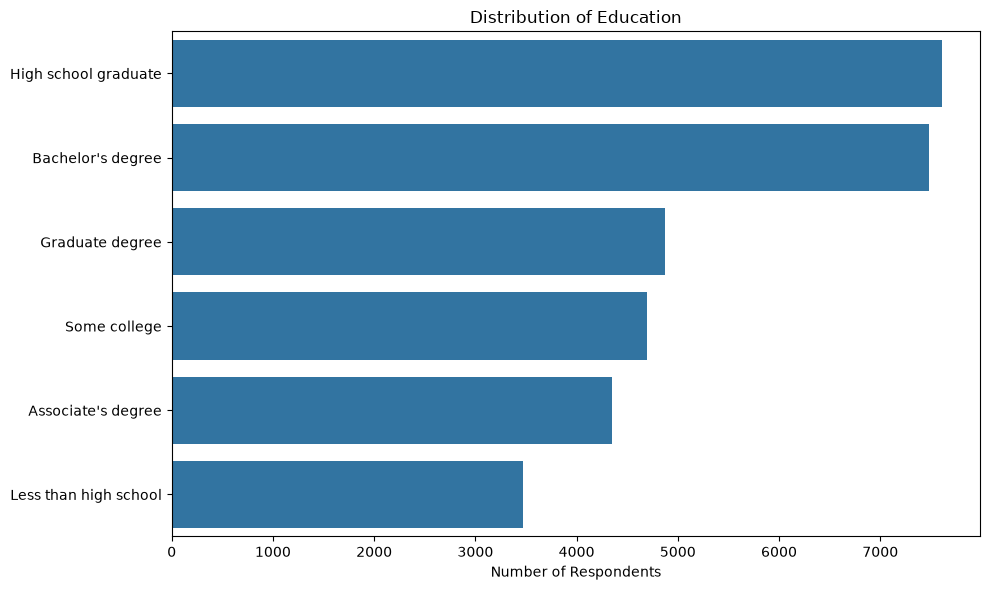

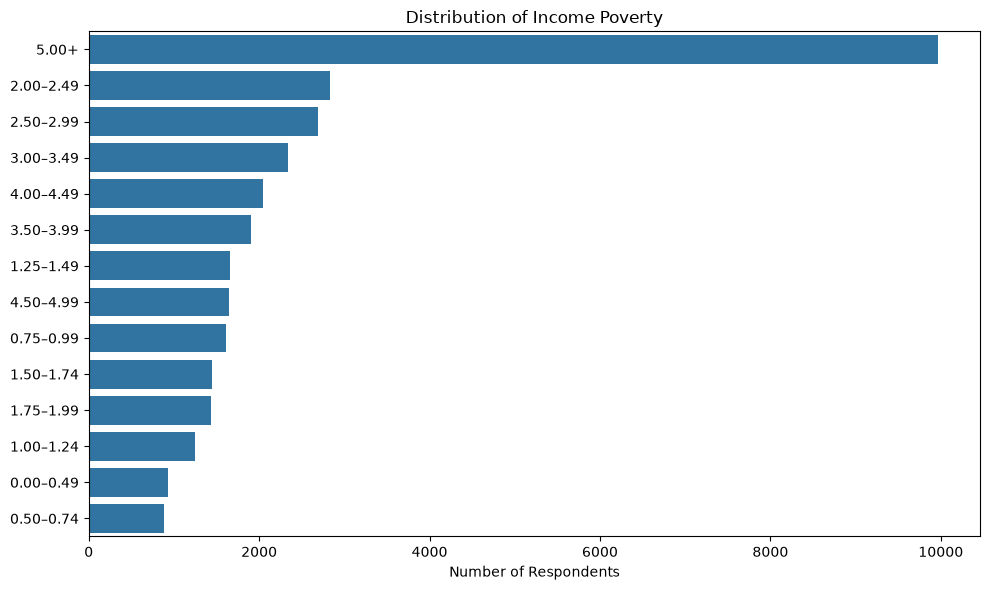

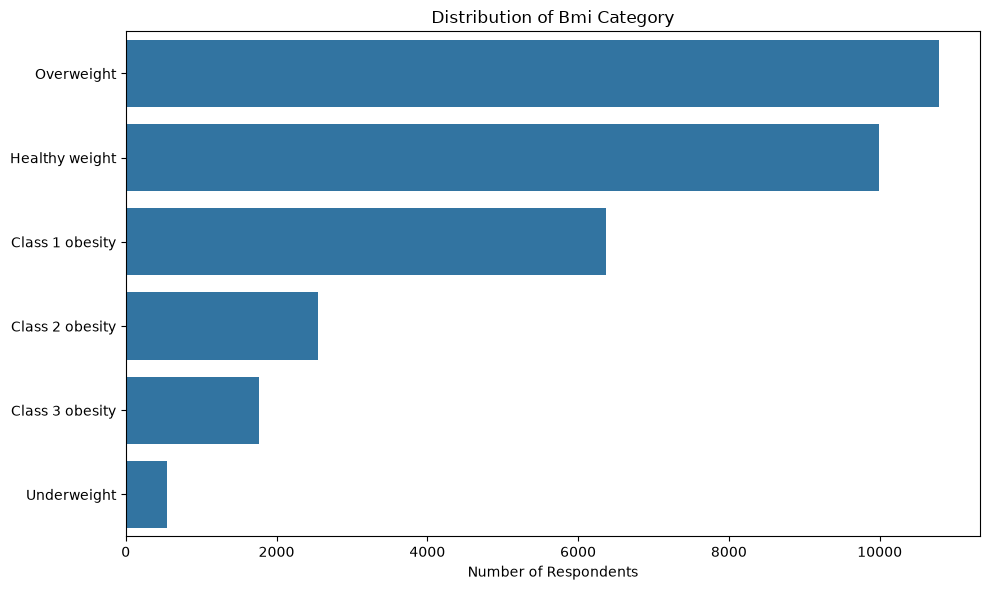

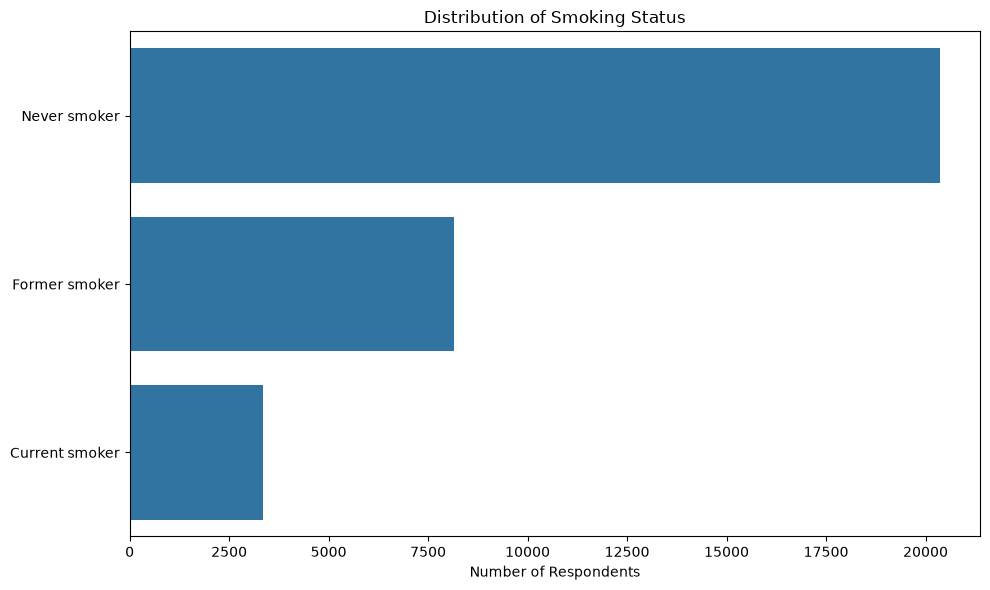

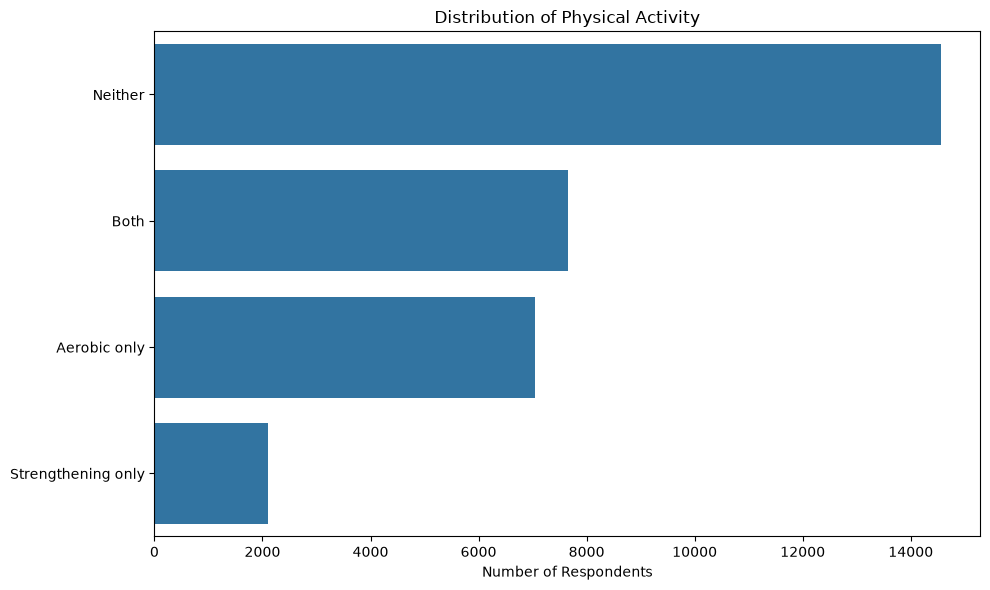

In [43]:
# 4 

variables = [
    "education",
    "income_poverty",
    "bmi_category",
    "smoking_status",
    "physical_activity"
]

for variable in variables:

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        y=variable,
        order=df[variable].value_counts().index
    )

    plt.title(
        f"Distribution of {variable.replace('_', ' ').title()}"
    )

    plt.xlabel("Number of Respondents")
    plt.ylabel("")

    plt.tight_layout()
    plt.show()

In [44]:
print(df["PHSTAT_A"].value_counts().sort_index())

PHSTAT_A
1     6302
2    10919
3    10037
4     4147
5     1208
7        9
9        7
Name: count, dtype: int64


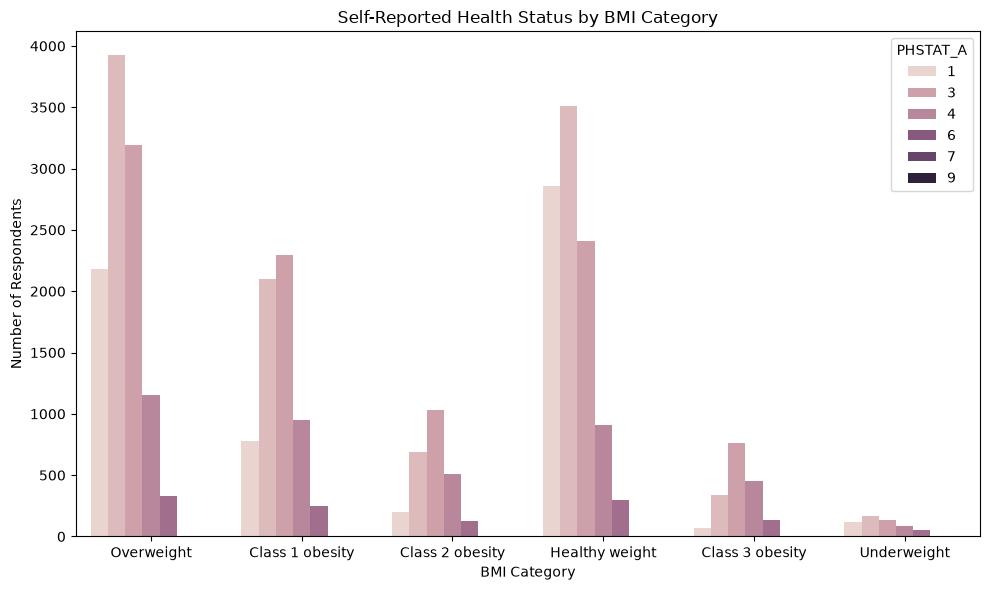

In [45]:
# BMI Graph: How many people are in each combination?

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="bmi_category",
    hue="PHSTAT_A"
)

plt.title("Self-Reported Health Status by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Number of Respondents")

plt.tight_layout()
plt.show()

In [46]:
print(df["PHSTAT_A"].value_counts().sort_index())

PHSTAT_A
1     6302
2    10919
3    10037
4     4147
5     1208
7        9
9        7
Name: count, dtype: int64


In [47]:
health_map = {
    1: "Excellent",
    2: "Very good",
    3: "Good",
    4: "Fair",
    5: "Poor"
}

df["health_status"] = df["PHSTAT_A"].map(health_map)

C:\Users\17322\AppData\Local\Temp\ipykernel_10136\1563750980.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["health_status"] = df["PHSTAT_A"].map(health_map)


In [48]:
print(df["health_status"].value_counts())

health_status
Very good    10919
Good         10037
Excellent     6302
Fair          4147
Poor          1208
Name: count, dtype: int64


In [49]:
# Crosstabulation percentage table
bmi_health = pd.crosstab(
    df["bmi_category"],
    df["health_status"],
    normalize="index"
) * 100

print(bmi_health.round(1))

health_status    Excellent  Fair  Good  Poor  Very good
bmi_category                                           
Class 1 obesity       12.2  14.9  36.1   3.9       33.0
Class 2 obesity        7.9  20.1  40.2   5.0       26.8
Class 3 obesity        4.1  25.8  43.3   7.6       19.3
Healthy weight        28.6   9.1  24.1   3.0       35.1
Overweight            20.2  10.7  29.6   3.1       36.4
Underweight           21.3  15.2  23.8   9.4       30.3


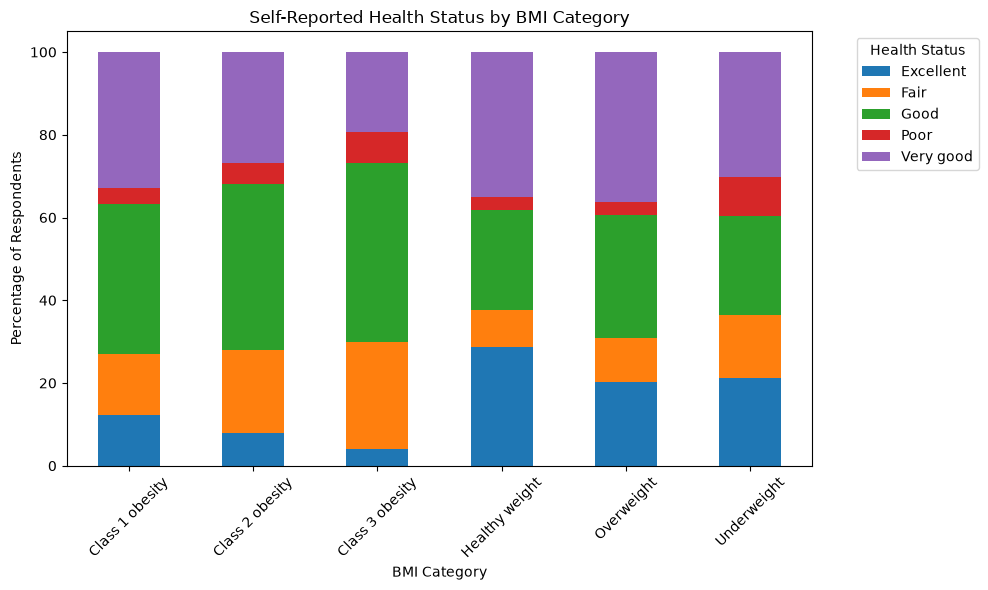

In [50]:
# BMI Graph: How is health status distributed within each BMI category?

bmi_health.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Self-Reported Health Status by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Percentage of Respondents")
plt.xticks(rotation=45)
plt.legend(title="Health Status", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [51]:
health_map = {
    1: "Excellent",
    2: "Very good",
    3: "Good",
    4: "Fair",
    5: "Poor"
}

df["health_status"] = df["PHSTAT_A"].map(health_map)

In [52]:
bmi_health = pd.crosstab(
    df["bmi_category"],
    df["health_status"],
    normalize="index"
) * 100

print(bmi_health.round(1))

health_status    Excellent  Fair  Good  Poor  Very good
bmi_category                                           
Class 1 obesity       12.2  14.9  36.1   3.9       33.0
Class 2 obesity        7.9  20.1  40.2   5.0       26.8
Class 3 obesity        4.1  25.8  43.3   7.6       19.3
Healthy weight        28.6   9.1  24.1   3.0       35.1
Overweight            20.2  10.7  29.6   3.1       36.4
Underweight           21.3  15.2  23.8   9.4       30.3


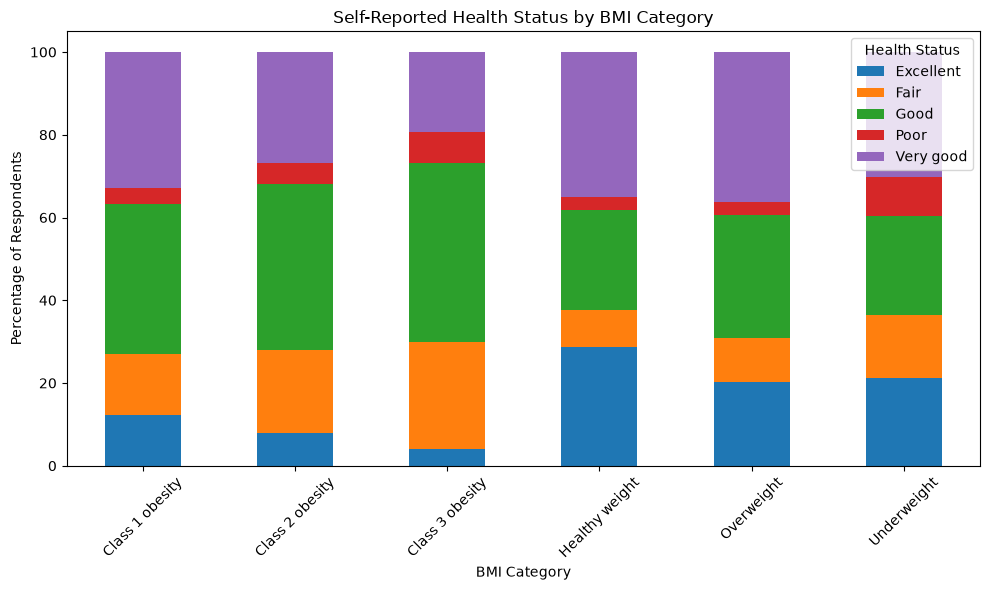

In [53]:
bmi_health.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Self-Reported Health Status by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Percentage of Respondents")
plt.xticks(rotation=45)
plt.legend(title="Health Status")

plt.tight_layout()
plt.show()

In [54]:
education_health = pd.crosstab(
    df["education"],
    df["health_status"],
    normalize="index"
) * 100

print(education_health.round(1))

health_status          Excellent  Fair  Good  Poor  Very good
education                                                    
Associate's degree          15.8  12.0  34.2   3.7       34.3
Bachelor's degree           24.7   7.8  25.4   1.5       40.4
Graduate degree             27.9   6.1  23.5   1.4       41.1
High school graduate        15.0  16.1  35.5   4.6       28.8
Less than high school       11.9  23.8  35.8   9.8       18.6
Some college                17.6  14.3  32.1   3.5       32.6


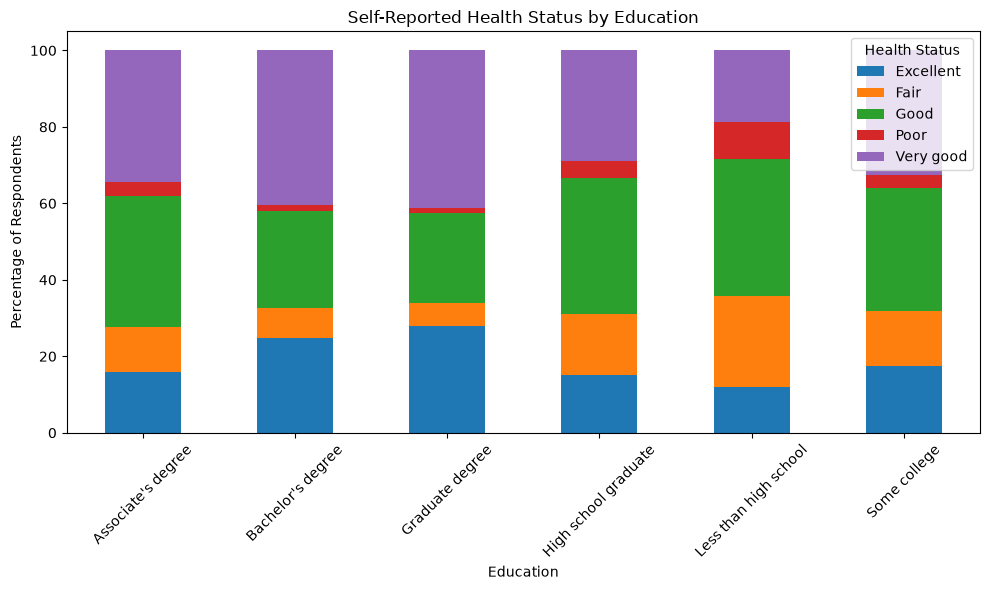

In [55]:
education_health.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Self-Reported Health Status by Education")
plt.xlabel("Education")
plt.ylabel("Percentage of Respondents")
plt.xticks(rotation=45)
plt.legend(title="Health Status")

plt.tight_layout()
plt.show()

In [56]:
smoking_health = pd.crosstab(
    df["smoking_status"],
    df["health_status"],
    normalize="index"
) * 100

print(smoking_health.round(1))

health_status   Excellent  Fair  Good  Poor  Very good
smoking_status                                        
Current smoker        9.7  20.9  36.0   7.9       25.5
Former smoker        13.7  15.6  33.4   4.9       32.5
Never smoker         23.2  10.2  28.7   2.4       35.4


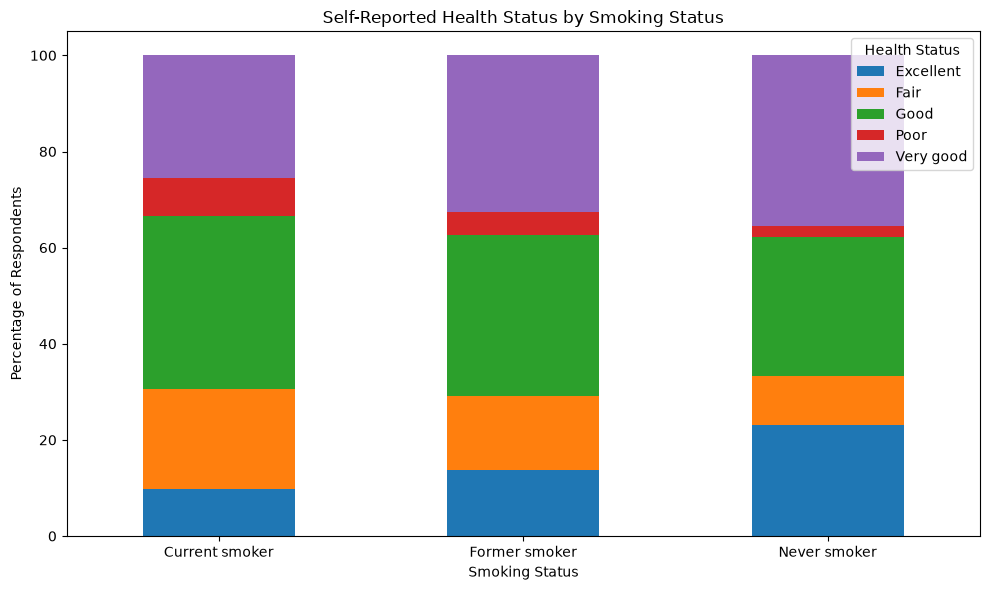

In [57]:
smoking_health.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Self-Reported Health Status by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Percentage of Respondents")
plt.xticks(rotation=0)
plt.legend(title="Health Status")

plt.tight_layout()
plt.show()

In [58]:
activity_health = pd.crosstab(
    df["physical_activity"],
    df["health_status"],
    normalize="index"
) * 100

print(activity_health.round(1))

health_status       Excellent  Fair  Good  Poor  Very good
physical_activity                                         
Aerobic only             20.5   9.4  30.1   1.8       38.2
Both                     33.0   4.9  21.0   0.7       40.3
Neither                  12.1  18.2  36.2   6.1       27.5
Strengthening only       16.3  13.9  29.4   3.6       36.8


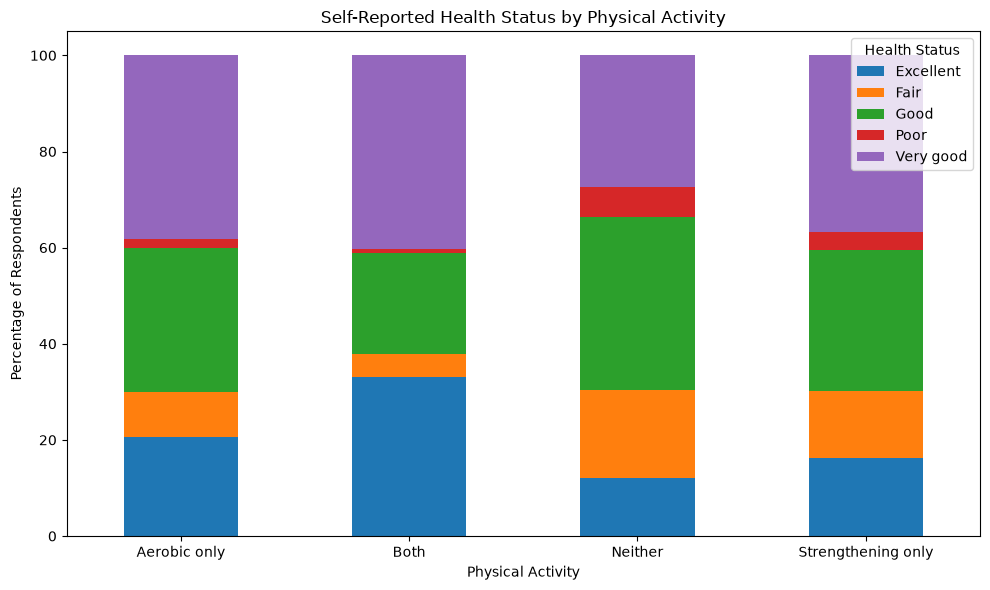

In [59]:
activity_health.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Self-Reported Health Status by Physical Activity")
plt.xlabel("Physical Activity")
plt.ylabel("Percentage of Respondents")
plt.xticks(rotation=0)
plt.legend(title="Health Status")

plt.tight_layout()
plt.show()

In [60]:
income_health = pd.crosstab(
    df["income_poverty"],
    df["health_status"],
    normalize="index"
) * 100

print(income_health.round(1))

health_status   Excellent  Fair  Good  Poor  Very good
income_poverty                                        
0.00–0.49            15.4  22.8  31.4   8.2       22.2
0.50–0.74            11.0  25.5  32.7  12.6       18.2
0.75–0.99            11.4  25.1  34.1   9.3       20.1
1.00–1.24            12.2  23.6  34.3   9.6       20.3
1.25–1.49            14.2  20.0  35.1   7.6       23.2
1.50–1.74            14.2  19.3  34.7   6.0       25.7
1.75–1.99            15.2  15.3  37.0   4.4       28.1
2.00–2.49            15.8  15.8  33.0   4.1       31.4
2.50–2.99            15.3  13.8  35.1   3.5       32.4
3.00–3.49            19.0  10.2  34.7   2.0       34.1
3.50–3.99            19.5   9.6  32.1   1.8       36.9
4.00–4.49            18.1   9.6  30.2   1.7       40.3
4.50–4.99            22.3   8.3  26.7   1.6       41.0
5.00+                26.7   6.1  25.2   1.2       40.8


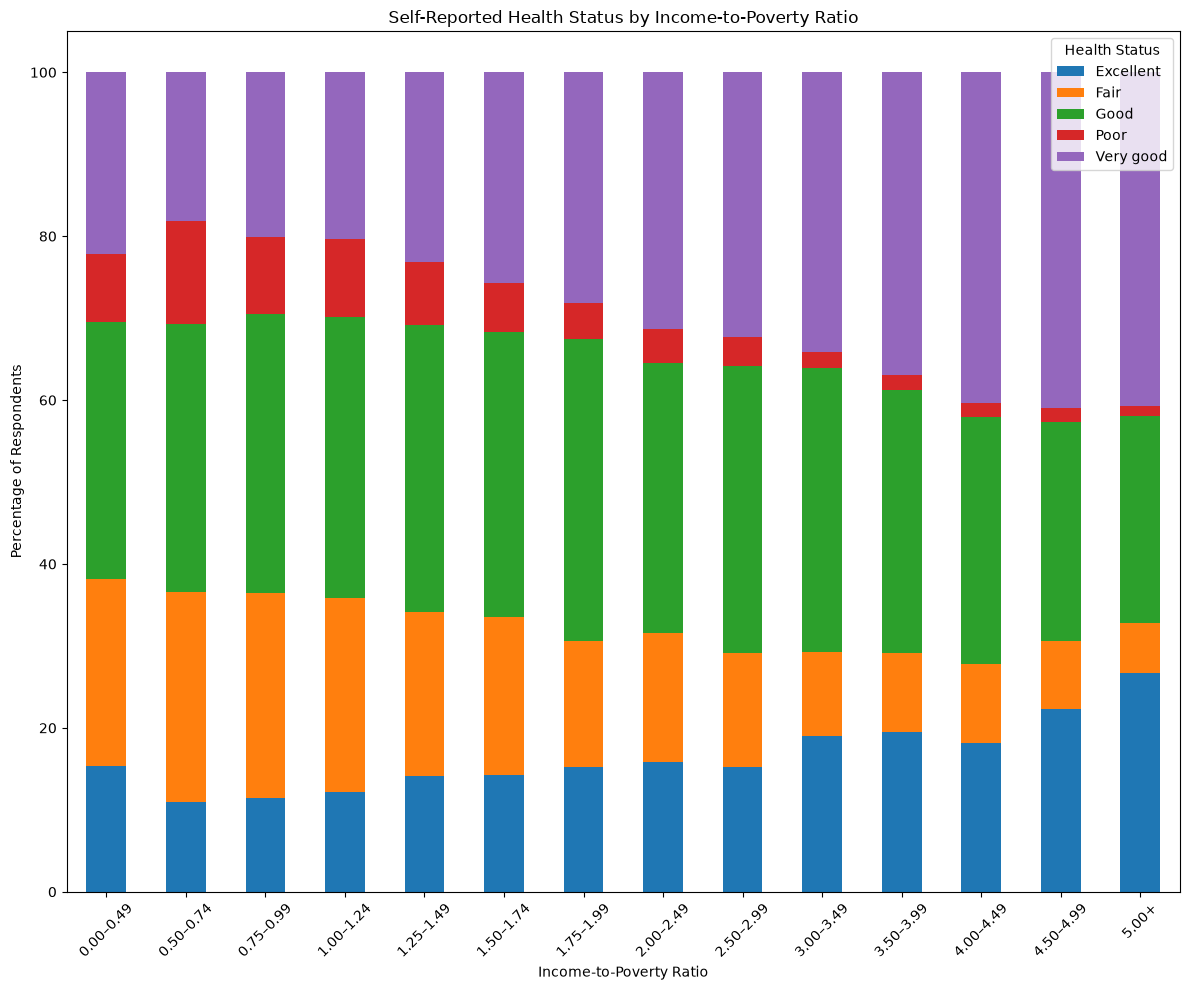

In [61]:
income_health.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 10)
)

plt.title("Self-Reported Health Status by Income-to-Poverty Ratio")
plt.xlabel("Income-to-Poverty Ratio")
plt.ylabel("Percentage of Respondents")
plt.xticks(rotation=45)
plt.legend(title="Health Status")

plt.tight_layout()
plt.show()

In [62]:
print(education_health.round(1))
print(smoking_health.round(1))
print(activity_health.round(1))
print(income_health.round(1))

health_status          Excellent  Fair  Good  Poor  Very good
education                                                    
Associate's degree          15.8  12.0  34.2   3.7       34.3
Bachelor's degree           24.7   7.8  25.4   1.5       40.4
Graduate degree             27.9   6.1  23.5   1.4       41.1
High school graduate        15.0  16.1  35.5   4.6       28.8
Less than high school       11.9  23.8  35.8   9.8       18.6
Some college                17.6  14.3  32.1   3.5       32.6
health_status   Excellent  Fair  Good  Poor  Very good
smoking_status                                        
Current smoker        9.7  20.9  36.0   7.9       25.5
Former smoker        13.7  15.6  33.4   4.9       32.5
Never smoker         23.2  10.2  28.7   2.4       35.4
health_status       Excellent  Fair  Good  Poor  Very good
physical_activity                                         
Aerobic only             20.5   9.4  30.1   1.8       38.2
Both                     33.0   4.9  21.0   0.7     

In [63]:
bmi_health = pd.crosstab(
    df["bmi_category"],
    df["health_status"],
    normalize="index"
) * 100

print(bmi_health.round(1))

health_status    Excellent  Fair  Good  Poor  Very good
bmi_category                                           
Class 1 obesity       12.2  14.9  36.1   3.9       33.0
Class 2 obesity        7.9  20.1  40.2   5.0       26.8
Class 3 obesity        4.1  25.8  43.3   7.6       19.3
Healthy weight        28.6   9.1  24.1   3.0       35.1
Overweight            20.2  10.7  29.6   3.1       36.4
Underweight           21.3  15.2  23.8   9.4       30.3


In [64]:
print(df["AGEP_A"].describe())

count    32629.000000
mean        53.453278
std         18.673458
min         18.000000
25%         37.000000
50%         55.000000
75%         69.000000
max         99.000000
Name: AGEP_A, dtype: float64


In [65]:
print(df["AGEP_A"].isnull().sum())

print(df["AGEP_A"].isna().sum())

0
0


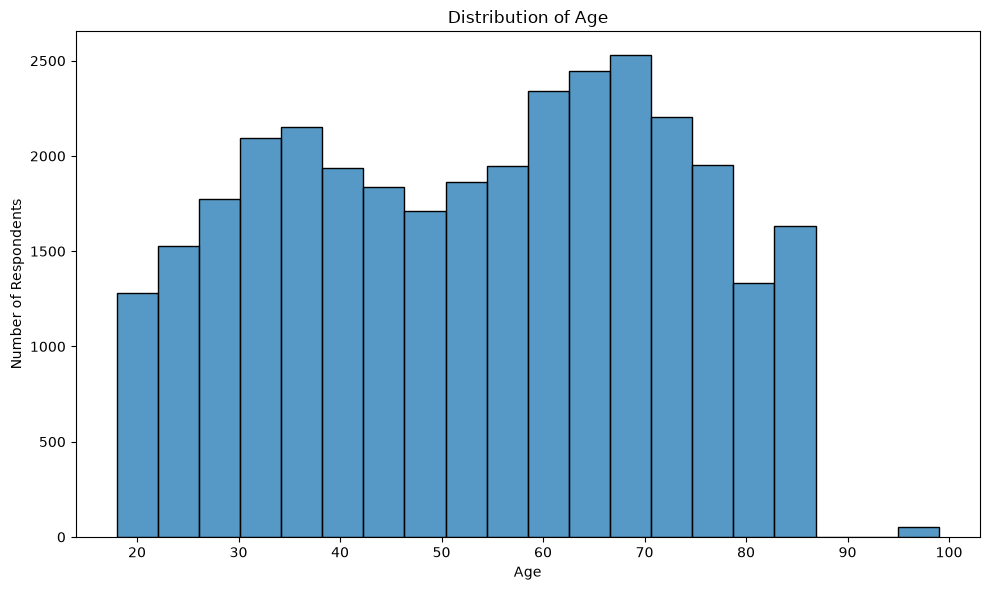

In [66]:
# Histogram: Distribution of Age

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="AGEP_A",
    bins=20
)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Respondents")

plt.tight_layout()
plt.show()

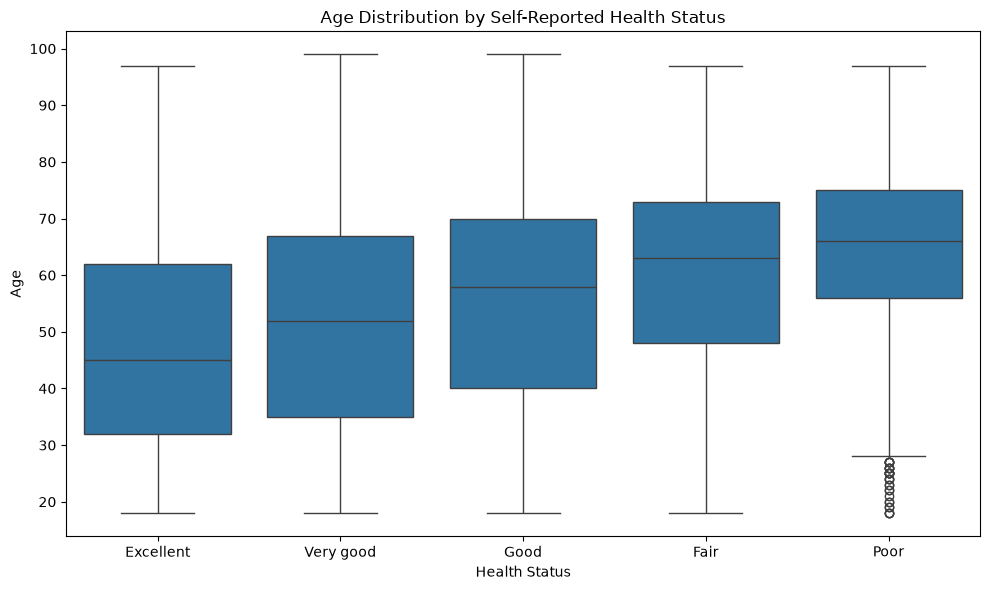

In [67]:
plt.figure(figsize = (10, 6))

sns.boxplot(
    data=df,
    x="health_status",
    y="AGEP_A"
)

plt.title("Age Distribution by Self-Reported Health Status")
plt.xlabel("Health Status")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

In [68]:
age_by_health = df.groupby(
    "health_status",
    observed=True
)["AGEP_A"].agg(["count", "mean", "median"])

print(age_by_health.round(1))

               count  mean  median
health_status                     
Excellent       6302  47.1    45.0
Fair            4147  59.9    63.0
Good           10037  55.5    58.0
Poor            1208  63.8    66.0
Very good      10919  51.6    52.0


In [69]:
print(df["AGEP_A"].value_counts().sort_index().head(20))

print(df["AGEP_A"].value_counts().sort_index().tail(20))

AGEP_A
18    236
19    235
20    258
21    251
22    302
23    370
24    356
25    375
26    428
27    424
28    426
29    425
30    501
31    479
32    537
33    536
34    545
35    579
36    497
37    531
Name: count, dtype: int64
AGEP_A
68     585
69     643
70     581
71     582
72     605
73     530
74     486
75     538
76     486
77     521
78     410
79     358
80     338
81     353
82     285
83     237
84     209
85    1189
97      48
99       4
Name: count, dtype: int64


In [70]:
print(df["AGEP_A"].describe())

count    32629.000000
mean        53.453278
std         18.673458
min         18.000000
25%         37.000000
50%         55.000000
75%         69.000000
max         99.000000
Name: AGEP_A, dtype: float64


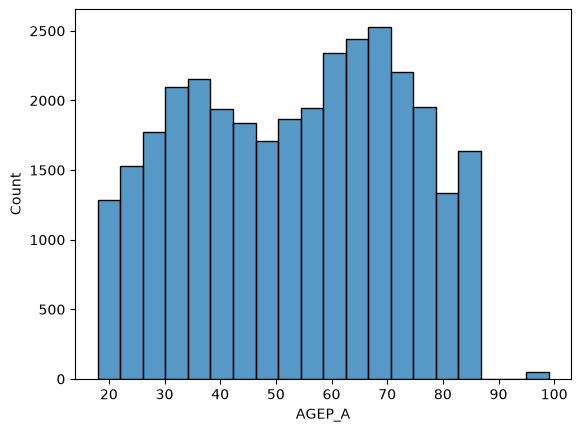

In [71]:
sns.histplot(data=df, x="AGEP_A", bins=20)
plt.show()

In [72]:
age_by_health = df.groupby(
    "health_status",
    observed=True
)["AGEP_A"].agg(["count", "mean", "median"])

print(age_by_health.round(1))

               count  mean  median
health_status                     
Excellent       6302  47.1    45.0
Fair            4147  59.9    63.0
Good           10037  55.5    58.0
Poor            1208  63.8    66.0
Very good      10919  51.6    52.0

In [73]:
# Conclusion: Age is strongly associated with self-reported health status in this dataset. Older respondents tend to report less favorable health.

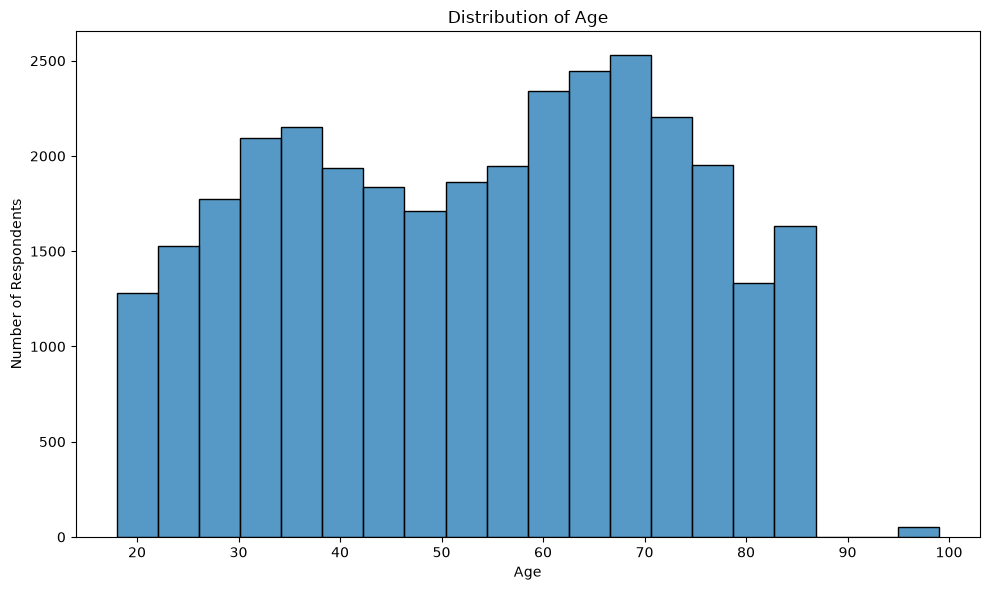

In [74]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="AGEP_A",
    bins=20
)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Respondents")

plt.tight_layout()
plt.show()

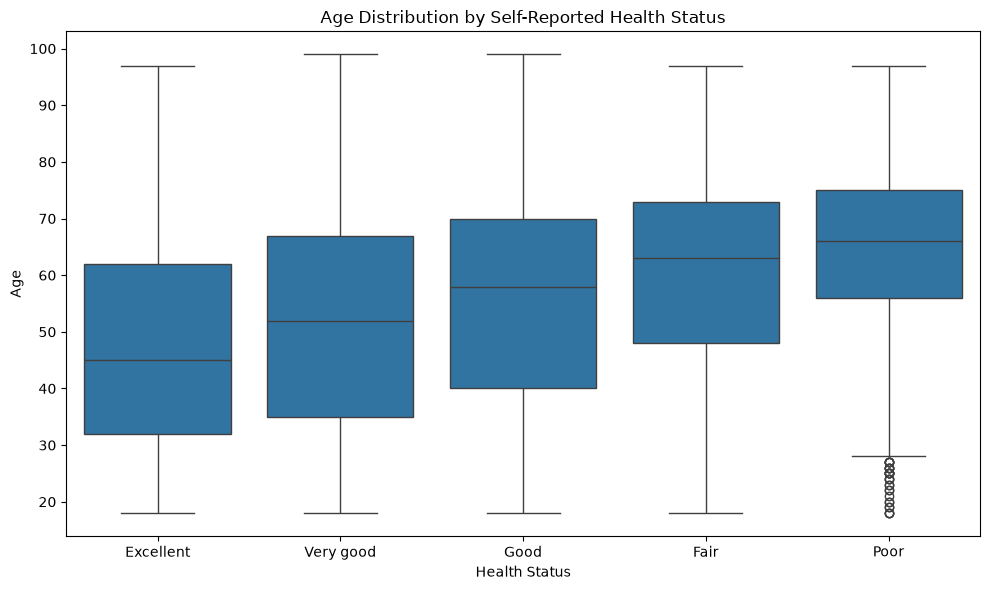

In [75]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="health_status",
    y="AGEP_A"
)

plt.title("Age Distribution by Self-Reported Health Status")
plt.xlabel("Health Status")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

In [76]:
# Check correlations for numerical variables

numeric_columns = [
    "AGEP_A",
    "RATCAT_A",
    "BMICAT_A",
    "SMKCIGST_A",
    "PA18_05R_A"
]

correlation_matrix = df[numeric_columns].corr()

print(correlation_matrix.round(2))

            AGEP_A  RATCAT_A  BMICAT_A  SMKCIGST_A  PA18_05R_A
AGEP_A        1.00     -0.01      0.02       -0.08       -0.11
RATCAT_A     -0.01      1.00     -0.05        0.11        0.14
BMICAT_A      0.02     -0.05      1.00        0.03       -0.08
SMKCIGST_A   -0.08      0.11      0.03        1.00        0.38
PA18_05R_A   -0.11      0.14     -0.08        0.38        1.00


In [77]:
health_numeric = {
    "Excellent": 1,
    "Very good": 2,
    "Good": 3,
    "Fair": 4,
    "Poor": 5
}

df["health_numeric"] = df["health_status"].map(health_numeric)

C:\Users\17322\AppData\Local\Temp\ipykernel_10136\3295422967.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["health_numeric"] = df["health_status"].map(health_numeric)


In [78]:
age_health_corr = df["AGEP_A"].corr(df["health_numeric"])

print("Correlation between age and health status:",
      round(age_health_corr, 3))

Correlation between age and health status: 0.236


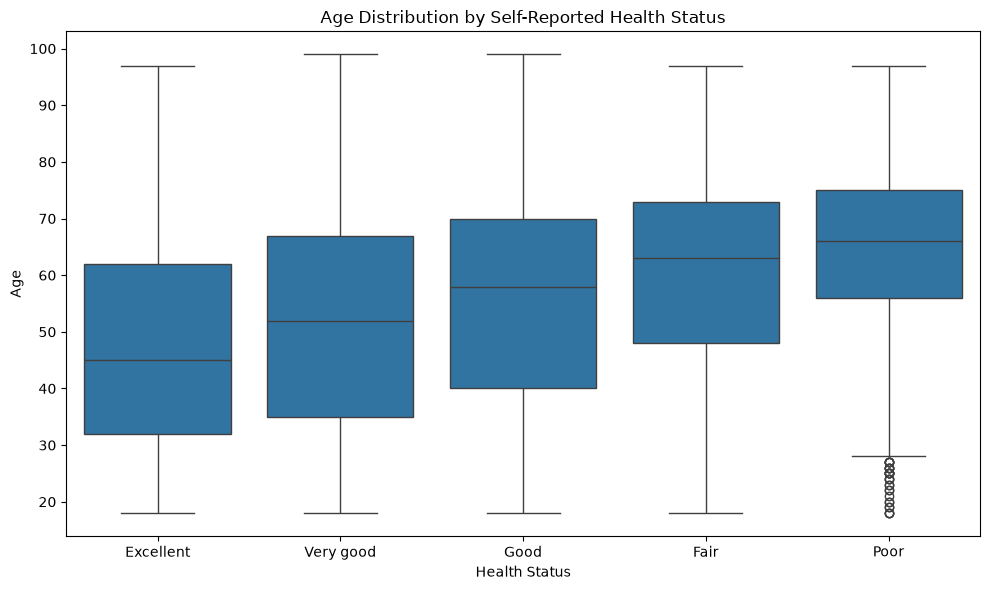

In [79]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="health_status",
    y="AGEP_A"
)

plt.title("Age Distribution by Self-Reported Health Status")
plt.xlabel("Health Status")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

In [80]:
print(df.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['RATCAT_A', 'INCTCFLG_A', 'IMPINCFLG_A', 'PPSU', 'PSTRAT',
       'WLKLEISTC_A', 'WLKTRANTC_A', 'HISPALLP_A', 'RACEALLP_A', 'ANYDIFF_A',
       ...
       'WTFA_A', 'HHX', 'POVRATTC_A', 'bmi_category', 'smoking_status',
       'physical_activity', 'education', 'income_poverty', 'health_status',
       'health_numeric'],
      dtype='str', length=637)>


In [81]:
# Finding missing values in main variables

analysis_columns = [
    "PHSTAT_A",
    "AGEP_A",
    "SEX_A",
    "HISPALLP_A",
    "EDUCP_A",
    "RATCAT_A",
    "BMICATD_A",
    "SMKCIGST_A",
    "PA18_05R_A"
]

missing_counts = df[analysis_columns].isnull().sum()

print(missing_counts)

PHSTAT_A        0
AGEP_A          0
SEX_A           0
HISPALLP_A      0
EDUCP_A         0
RATCAT_A        0
BMICATD_A     600
SMKCIGST_A      0
PA18_05R_A      0
dtype: int64


In [82]:
# Examining the missing codes

special_codes = [7, 8, 9, 97, 98, 99]

for column in analysis_columns:
    counts = df[column].isin(special_codes).sum()

    if counts > 0:
        print(column, ":", counts)

PHSTAT_A : 16
AGEP_A : 52
SEX_A : 5
HISPALLP_A : 411
EDUCP_A : 14273
RATCAT_A : 6960
SMKCIGST_A : 737
PA18_05R_A : 1283


In [83]:
df = df.replace([7, 8, 9, 97, 98, 99], np.nan)

In [84]:
# Check how much data is being lost

cleaned_columns = [
    "health_status",
    "education",
    "income_poverty",
    "bmi_category",
    "smoking_status",
    "physical_activity"
]

missing_cleaned = df[cleaned_columns].isnull().sum()

print(missing_cleaned)

health_status          16
education             147
income_poverty          0
bmi_category          600
smoking_status        753
physical_activity    1283
dtype: int64


In [85]:
missing_percentage = (
    df[cleaned_columns].isnull().mean() * 100
)

print(missing_percentage.round(2))

health_status        0.05
education            0.45
income_poverty       0.00
bmi_category         1.84
smoking_status       2.31
physical_activity    3.93
dtype: float64


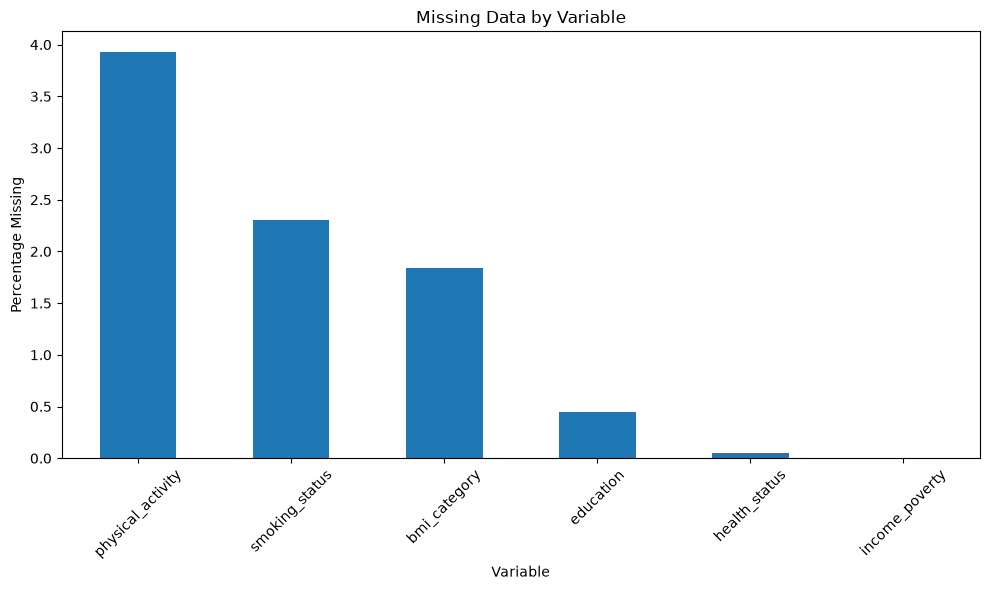

In [86]:
missing_percentage.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Missing Data by Variable")
plt.xlabel("Variable")
plt.ylabel("Percentage Missing")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [87]:
# Checking how many complete observations there are

complete_cases = df[cleaned_columns].dropna()

print("Original observations:", len(df))
print("Complete observations:", len(complete_cases))
print(
    "Percentage complete:",
    round(len(complete_cases) / len(df) * 100, 2),
    "%"
)

Original observations: 32629
Complete observations: 30648
Percentage complete: 93.93 %


In [88]:
# Special codes

for column in analysis_columns:
    counts = df[column].isin([7, 8, 9, 97, 98, 99]).sum()

    if counts > 0:
        print(column, ":", counts)

In [89]:
# Missing percentages

print(
    (df[cleaned_columns].isnull().mean() * 100).round(2)
)

health_status        0.05
education            0.45
income_poverty       0.00
bmi_category         1.84
smoking_status       2.31
physical_activity    3.93
dtype: float64


In [90]:
# Complete observations

complete_cases = df[cleaned_columns].dropna()

print("Original observations:", len(df))
print("Complete observations:", len(complete_cases))
print(
    "Percentage complete:",
    round(len(complete_cases) / len(df) * 100, 2),
    "%"
)

Original observations: 32629
Complete observations: 30648
Percentage complete: 93.93 %


In [91]:
df["activity_missing"] = df["physical_activity"].isna()

print(
    df.groupby("activity_missing")["AGEP_A"].mean()
)

print()

print(
    pd.crosstab(
        df["activity_missing"],
        df["health_status"],
        normalize="index"
    ).round(3) * 100
)

activity_missing
False    53.336570
True     54.538099
Name: AGEP_A, dtype: float64

health_status     Excellent  Fair  Good  Poor  Very good
activity_missing                                        
False                  19.3  12.7  30.7   3.7       33.6
True                   18.7  13.0  33.7   5.0       29.6


In [92]:
# We don't see evidence from this simple check that missing physical-activity responses are dramatically different from the rest of the sample.

In [93]:
model_columns = [
    "health_status",
    "AGEP_A",
    "education",
    "income_poverty",
    "bmi_category",
    "smoking_status",
    "physical_activity"
]

model_df = df[model_columns].dropna()

print(model_df.shape)
print(model_df.head())

(30623, 7)
  health_status  AGEP_A             education income_poverty     bmi_category  \
0     Excellent    49.0          Some college      2.50–2.99       Overweight   
1     Very good    53.0          Some college      2.00–2.49       Overweight   
2     Very good    82.0          Some college      1.75–1.99  Class 1 obesity   
3          Good    42.0  High school graduate      4.00–4.49       Overweight   
4          Good    38.0       Graduate degree          5.00+       Overweight   

  smoking_status physical_activity  
0  Former smoker      Aerobic only  
1  Former smoker           Neither  
2  Former smoker           Neither  
3  Former smoker           Neither  
4   Never smoker              Both  


In [94]:
print(model_df["health_status"].value_counts())

health_status
Very good    10327
Good          9344
Excellent     5960
Fair          3878
Poor          1114
Name: count, dtype: int64


## 4. Creating the Target Variable

Self-rated health was originally recorded using five categories: Excellent, Very good, Good, Fair, and Poor.

For this analysis, the outcome was converted into a binary variable. Respondents reporting Fair or Poor health were classified as having poor self-rated health, while respondents reporting Excellent, Very good, or Good health were classified as Good or Better.

In [95]:
# Create binary target

model_df["poor_health"] = model_df["health_status"].isin(
    ["Fair", "Poor"]
).astype(int)

# Check the new target
print(model_df["poor_health"].value_counts())

print("\nPercentages:")
print(model_df["poor_health"].value_counts(normalize=True) * 100)

poor_health
0    25631
1     4992
Name: count, dtype: int64

Percentages:
poor_health
0    83.698527
1    16.301473
Name: proportion, dtype: float64


In [96]:
# Features
X = model_df.drop(
    ["health_status", "poor_health"],
    axis=1
)

# Binary target
y = model_df["poor_health"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30623, 6)
y shape: (30623,)


In [97]:
print("\nClass distribution:")
print(y.value_counts())

print("\nClass percentages:")
print(y.value_counts(normalize=True) * 100)


Class distribution:
poor_health
0    25631
1     4992
Name: count, dtype: int64

Class percentages:
poor_health
0    83.698527
1    16.301473
Name: proportion, dtype: float64


## 5. Data Preparation

The data was divided into training and testing sets using stratified sampling to preserve the proportion of respondents reporting Fair or Poor health.

Categorical variables were one-hot encoded, while age was retained as a numeric variable. Feature scaling was applied for Logistic Regression.

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

X_train: (24498, 6)
X_test: (6125, 6)
y_train: (24498,)
y_test: (6125,)

Training class distribution:
poor_health
0    0.836966
1    0.163034
Name: proportion, dtype: float64

Testing class distribution:
poor_health
0    0.837061
1    0.162939
Name: proportion, dtype: float64


In [99]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [100]:
print(X.columns)

print(X.dtypes)

Index(['AGEP_A', 'education', 'income_poverty', 'bmi_category',
       'smoking_status', 'physical_activity'],
      dtype='str')
AGEP_A               float64
education                str
income_poverty           str
bmi_category             str
smoking_status           str
physical_activity        str
dtype: object


In [101]:
# One-hot encode categorical variables
X_encoded = pd.get_dummies(
    X,
    columns=[
        "education",
        "income_poverty",
        "bmi_category",
        "smoking_status",
        "physical_activity"
    ],
    drop_first=True
)

print("Encoded X shape:", X_encoded.shape)
print(X_encoded.dtypes)

Encoded X shape: (30623, 29)
AGEP_A                                  float64
education_Bachelor's degree                bool
education_Graduate degree                  bool
education_High school graduate             bool
education_Less than high school            bool
education_Some college                     bool
income_poverty_0.50–0.74                   bool
income_poverty_0.75–0.99                   bool
income_poverty_1.00–1.24                   bool
income_poverty_1.25–1.49                   bool
income_poverty_1.50–1.74                   bool
income_poverty_1.75–1.99                   bool
income_poverty_2.00–2.49                   bool
income_poverty_2.50–2.99                   bool
income_poverty_3.00–3.49                   bool
income_poverty_3.50–3.99                   bool
income_poverty_4.00–4.49                   bool
income_poverty_4.50–4.99                   bool
income_poverty_5.00+                       bool
bmi_category_Class 2 obesity               bool
bmi_categor

In [102]:
print(X.isnull().sum())

print("\nNumber of unique values:")
print(X.nunique())

AGEP_A               0
education            0
income_poverty       0
bmi_category         0
smoking_status       0
physical_activity    0
dtype: int64

Number of unique values:
AGEP_A               68
education             6
income_poverty       14
bmi_category          6
smoking_status        3
physical_activity     4
dtype: int64


In [103]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "education",
    "income_poverty",
    "bmi_category",
    "smoking_status",
    "physical_activity"
]

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

X_train_encoded = encoder.fit_transform(X_train[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

In [104]:
import numpy as np

X_train_encoded = np.column_stack([
    X_train["AGEP_A"].values,
    X_train_encoded
])

X_test_encoded = np.column_stack([
    X_test["AGEP_A"].values,
    X_test_encoded
])

print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape:", X_test_encoded.shape)

X_train_encoded shape: (24498, 29)
X_test_encoded shape: (6125, 29)


In [105]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (24498, 29)
X_test_scaled shape: (6125, 29)


## 6. Model Training and Evaluation

Three machine learning models were evaluated:

1. Logistic Regression
2. Random Forest
3. Gradient Boosting

Because Fair/Poor health represented the minority class, model evaluation considered precision, recall, and F1-score in addition to overall accuracy.

In [106]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [107]:
log_predictions = log_model.predict(X_test_scaled)

In [108]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, log_predictions))

print("\nClassification Report:")
print(classification_report(
    y_test,
    log_predictions,
    target_names=["Good or Better", "Fair or Poor"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, log_predictions))

Logistic Regression Accuracy: 0.8370612244897959

Classification Report:
                precision    recall  f1-score   support

Good or Better       0.85      0.97      0.91      5127
  Fair or Poor       0.50      0.14      0.21       998

      accuracy                           0.84      6125
     macro avg       0.68      0.55      0.56      6125
  weighted avg       0.80      0.84      0.80      6125


Confusion Matrix:
[[4992  135]
 [ 863  135]]


In [109]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_encoded, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [110]:
rf_predictions = rf_model.predict(X_test_encoded)

In [111]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_predictions))

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_predictions,
    target_names=["Good or Better", "Fair or Poor"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

Random Forest Accuracy: 0.7537959183673469

Classification Report:
                precision    recall  f1-score   support

Good or Better       0.87      0.83      0.85      5127
  Fair or Poor       0.30      0.38      0.34       998

      accuracy                           0.75      6125
     macro avg       0.59      0.60      0.59      6125
  weighted avg       0.78      0.75      0.77      6125


Confusion Matrix:
[[4236  891]
 [ 617  381]]


In [112]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    random_state=42
)

gb_model.fit(X_train_encoded, y_train)

,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [113]:
gb_predictions = gb_model.predict(X_test_encoded)

In [114]:
print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, gb_predictions))

print("\nClassification Report:")
print(classification_report(
    y_test,
    gb_predictions,
    target_names=["Good or Better", "Fair or Poor"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_predictions))

Gradient Boosting Accuracy: 0.8365714285714285

Classification Report:
                precision    recall  f1-score   support

Good or Better       0.85      0.97      0.91      5127
  Fair or Poor       0.49      0.14      0.22       998

      accuracy                           0.84      6125
     macro avg       0.67      0.56      0.57      6125
  weighted avg       0.80      0.84      0.80      6125


Confusion Matrix:
[[4980  147]
 [ 854  144]]


## 7. Model Comparison

Although Logistic Regression and Gradient Boosting achieved higher overall accuracy, Random Forest achieved the strongest performance for identifying respondents reporting Fair or Poor health.

For this reason, Random Forest was selected for further feature-importance analysis.

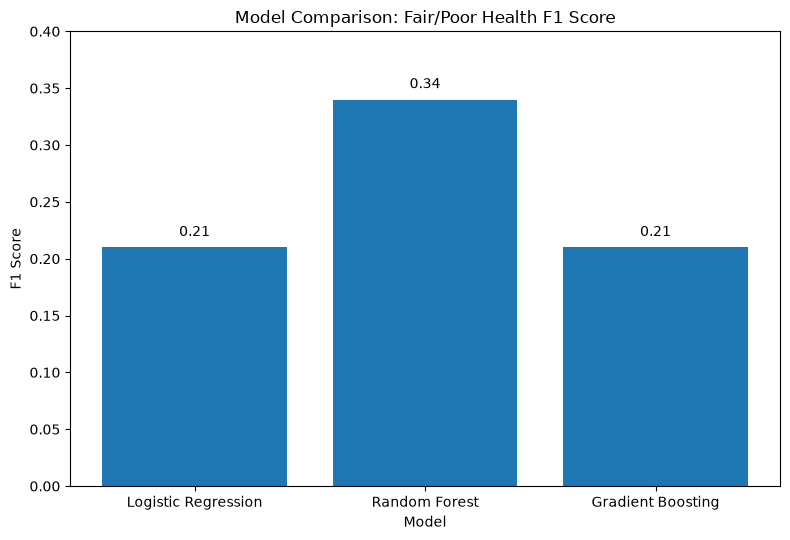

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Fair/Poor F1": [
        0.21,
        0.34,
        0.21
    ]
})

plt.figure(figsize=(8, 5.5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Fair/Poor F1"]
)

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Model Comparison: Fair/Poor Health F1 Score")
plt.ylim(0, 0.4)

for i, value in enumerate(model_comparison["Fair/Poor F1"]):
    plt.text(
        i,
        value + 0.01,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Random Forest most accurately predicts fair/poor

In [ ]:
# Get feature names from the encoder
encoded_feature_names = encoder.get_feature_names_out(
    categorical_features
)

# Combine age with the encoded feature names
feature_names = np.concatenate([
    ["AGEP_A"],
    encoded_feature_names
])

# Get Random Forest feature importance
rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

# Sort from most to least important
rf_importance = rf_importance.sort_values(
    "importance",
    ascending=False
)

print(rf_importance)

                                 feature  importance
0                                 AGEP_A    0.473916
27             physical_activity_Neither    0.049629
18                  income_poverty_5.00+    0.035815
26                physical_activity_Both    0.034030
22               bmi_category_Overweight    0.028053
25           smoking_status_Never smoker    0.027727
21           bmi_category_Healthy weight    0.026320
4        education_Less than high school    0.022718
3         education_High school graduate    0.022499
5                 education_Some college    0.021628
24          smoking_status_Former smoker    0.020325
1            education_Bachelor's degree    0.019349
20          bmi_category_Class 3 obesity    0.019134
19          bmi_category_Class 2 obesity    0.017855
2              education_Graduate degree    0.016114
12              income_poverty_2.00–2.49    0.014716
28  physical_activity_Strengthening only    0.014412
13              income_poverty_2.50–2.99    0.

In [ ]:
print("Number of encoded feature names:", len(encoded_feature_names))
print("Number of feature columns:", X_train_encoded.shape[1])
print("Number of importances:", len(rf_model.feature_importances_))

Number of encoded feature names: 28
Number of feature columns: 30
Number of importances: 30


In [ ]:
print(encoder.get_feature_names_out())

["education_Bachelor's degree" 'education_Graduate degree'
 'education_High school graduate' 'education_Less than high school'
 'education_Some college' 'income_poverty_0.50–0.74'
 'income_poverty_0.75–0.99' 'income_poverty_1.00–1.24'
 'income_poverty_1.25–1.49' 'income_poverty_1.50–1.74'
 'income_poverty_1.75–1.99' 'income_poverty_2.00–2.49'
 'income_poverty_2.50–2.99' 'income_poverty_3.00–3.49'
 'income_poverty_3.50–3.99' 'income_poverty_4.00–4.49'
 'income_poverty_4.50–4.99' 'income_poverty_5.00+'
 'bmi_category_Class 2 obesity' 'bmi_category_Class 3 obesity'
 'bmi_category_Healthy weight' 'bmi_category_Overweight'
 'bmi_category_Underweight' 'smoking_status_Former smoker'
 'smoking_status_Never smoker' 'physical_activity_Both'
 'physical_activity_Neither' 'physical_activity_Strengthening only']


In [ ]:
# Encode categorical variables again
X_train_cat = encoder.transform(X_train[categorical_features])
X_test_cat = encoder.transform(X_test[categorical_features])

# Create DataFrames with the correct feature names
X_train_encoded_df = pd.DataFrame(
    X_train_cat,
    columns=encoded_feature_names,
    index=X_train.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_cat,
    columns=encoded_feature_names,
    index=X_test.index
)

# Add age
X_train_encoded_df.insert(
    0,
    "AGEP_A",
    X_train["AGEP_A"]
)

X_test_encoded_df.insert(
    0,
    "AGEP_A",
    X_test["AGEP_A"]
)

print("X_train_encoded_df shape:", X_train_encoded_df.shape)
print("X_test_encoded_df shape:", X_test_encoded_df.shape)

X_train_encoded_df shape: (24498, 29)
X_test_encoded_df shape: (6125, 29)


In [ ]:
# Balancing model

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_encoded_df, y_train)

rf_predictions = rf_model.predict(X_test_encoded_df)

In [ ]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_predictions))

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_predictions,
    target_names=["Good or Better", "Fair or Poor"]
))

Random Forest Accuracy: 0.7537959183673469

Classification Report:
                precision    recall  f1-score   support

Good or Better       0.87      0.83      0.85      5127
  Fair or Poor       0.30      0.38      0.34       998

      accuracy                           0.75      6125
     macro avg       0.59      0.60      0.59      6125
  weighted avg       0.78      0.75      0.77      6125



## 8. Factor Importance

Grouped permutation importance was used to evaluate the predictive contribution of each original factor.

Unlike standard Random Forest feature importance, grouped permutation importance evaluates entire variables together. This is important because categorical variables such as education and income were represented by multiple one-hot encoded columns.

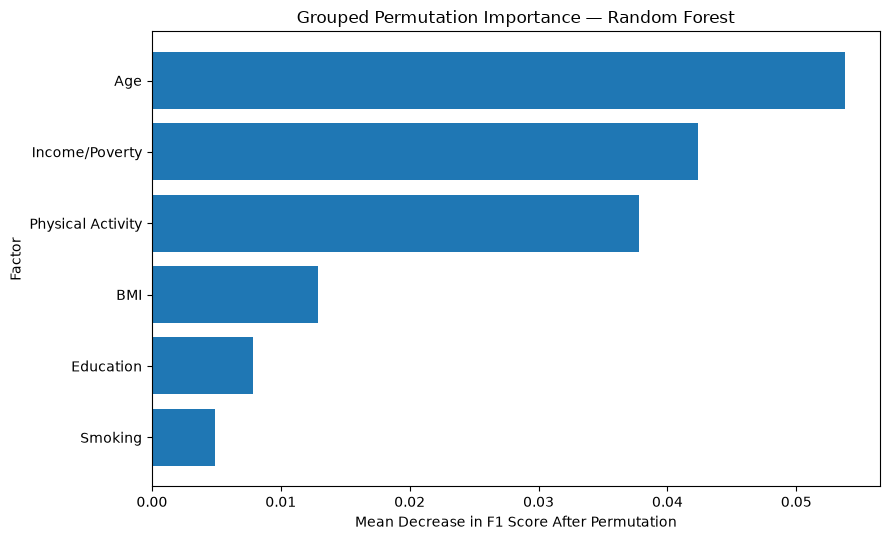

In [ ]:
import matplotlib.pyplot as plt

plot_data = grouped_importance.sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(9, 5.5))

plt.barh(
    plot_data["factor"],
    plot_data["importance"]
)

plt.xlabel("Mean Decrease in F1 Score After Permutation")
plt.ylabel("Factor")
plt.title("Grouped Permutation Importance — Random Forest")

plt.tight_layout()
plt.show()

In [ ]:
rf_importance = pd.DataFrame({
    "feature": X_train_encoded_df.columns,
    "importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "importance",
    ascending=False
)

print(rf_importance)

                                 feature  importance
0                                 AGEP_A    0.473916
27             physical_activity_Neither    0.049629
18                  income_poverty_5.00+    0.035815
26                physical_activity_Both    0.034030
22               bmi_category_Overweight    0.028053
25           smoking_status_Never smoker    0.027727
21           bmi_category_Healthy weight    0.026320
4        education_Less than high school    0.022718
3         education_High school graduate    0.022499
5                 education_Some college    0.021628
24          smoking_status_Former smoker    0.020325
1            education_Bachelor's degree    0.019349
20          bmi_category_Class 3 obesity    0.019134
19          bmi_category_Class 2 obesity    0.017855
2              education_Graduate degree    0.016114
12              income_poverty_2.00–2.49    0.014716
28  physical_activity_Strengthening only    0.014412
13              income_poverty_2.50–2.99    0.

In [ ]:
# Create a copy of the feature importance data
importance_by_factor = rf_importance.copy()

# Assign each feature to its original variable
def get_factor(feature):
    if feature == "AGEP_A":
        return "Age"
    elif feature.startswith("education_"):
        return "Education"
    elif feature.startswith("income_poverty_"):
        return "Income/Poverty"
    elif feature.startswith("bmi_category_"):
        return "BMI"
    elif feature.startswith("smoking_status_"):
        return "Smoking"
    elif feature.startswith("physical_activity_"):
        return "Physical Activity"

importance_by_factor["factor"] = (
    importance_by_factor["feature"].apply(get_factor)
)

# Sum importance within each original factor
factor_importance = (
    importance_by_factor
    .groupby("factor")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print(factor_importance)

factor
Age                  0.473916
Income/Poverty       0.178382
Education            0.102310
BMI                  0.099269
Physical Activity    0.098071
Smoking              0.048052
Name: importance, dtype: float64


In [ ]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_model,
    X_test_encoded_df,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

perm_importance = pd.DataFrame({
    "feature": X_test_encoded_df.columns,
    "importance": perm_result.importances_mean
})

perm_importance = perm_importance.sort_values(
    "importance",
    ascending=False
)

print(perm_importance)

                                 feature  importance
0                                 AGEP_A    0.053119
27             physical_activity_Neither    0.032567
24          smoking_status_Former smoker    0.007403
18                  income_poverty_5.00+    0.007049
20          bmi_category_Class 3 obesity    0.006022
21           bmi_category_Healthy weight    0.005930
3         education_High school graduate    0.003769
4        education_Less than high school    0.003631
15              income_poverty_3.50–3.99    0.002860
14              income_poverty_3.00–3.49    0.002710
6               income_poverty_0.50–0.74    0.002659
8               income_poverty_1.00–1.24    0.002495
26                physical_activity_Both    0.001896
23              bmi_category_Underweight    0.001879
16              income_poverty_4.00–4.49    0.001679
5                 education_Some college    0.000570
17              income_poverty_4.50–4.99    0.000528
10              income_poverty_1.50–1.74    0.

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

# Make a copy of the test data
X_test_permuted = X_test_encoded_df.copy()

# Define the original factors and their encoded columns
factor_columns = {
    "Age": ["AGEP_A"],
    "Income/Poverty": [
        col for col in X_test_encoded_df.columns
        if col.startswith("income_poverty_")
    ],
    "Education": [
        col for col in X_test_encoded_df.columns
        if col.startswith("education_")
    ],
    "BMI": [
        col for col in X_test_encoded_df.columns
        if col.startswith("bmi_category_")
    ],
    "Physical Activity": [
        col for col in X_test_encoded_df.columns
        if col.startswith("physical_activity_")
    ],
    "Smoking": [
        col for col in X_test_encoded_df.columns
        if col.startswith("smoking_status_")
    ]
}

# Baseline F1 score
baseline_predictions = rf_model.predict(X_test_encoded_df)
baseline_f1 = f1_score(y_test, baseline_predictions)

print("Baseline F1:", baseline_f1)

# Calculate grouped permutation importance
grouped_importance = []

for factor, columns in factor_columns.items():

    scores = []

    for i in range(10):

        X_permuted = X_test_encoded_df.copy()

        # Use the same permutation for all dummy columns
        permutation = np.random.permutation(len(X_permuted))

        for column in columns:
            X_permuted[column] = X_permuted[column].iloc[
                permutation
            ].values

        predictions = rf_model.predict(X_permuted)

        permuted_f1 = f1_score(y_test, predictions)

        scores.append(baseline_f1 - permuted_f1)

    grouped_importance.append({
        "factor": factor,
        "importance": np.mean(scores)
    })

grouped_importance = pd.DataFrame(
    grouped_importance
).sort_values(
    "importance",
    ascending=False
)

print("\nGrouped Permutation Importance:")
print(grouped_importance)

Baseline F1: 0.3356828193832599

Grouped Permutation Importance:
              factor  importance
0                Age    0.053804
1     Income/Poverty    0.042337
4  Physical Activity    0.037789
3                BMI    0.012856
2          Education    0.007875
5            Smoking    0.004904


In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        0.8369,
        0.7538,
        0.8366
    ],
    "Fair/Poor Precision": [
        0.50,
        0.30,
        0.49
    ],
    "Fair/Poor Recall": [
        0.14,
        0.38,
        0.14
    ],
    "Fair/Poor F1": [
        0.21,
        0.34,
        0.22
    ],
    "Macro F1": [
        0.56,
        0.59,
        0.57
    ]
})

print(model_comparison)

                 Model  Accuracy  Fair/Poor Precision  Fair/Poor Recall  \
0  Logistic Regression    0.8369                 0.50              0.14   
1        Random Forest    0.7538                 0.30              0.38   
2    Gradient Boosting    0.8366                 0.49              0.14   

   Fair/Poor F1  Macro F1  
0          0.21      0.56  
1          0.34      0.59  
2          0.22      0.57  


In [ ]:
# Conclusion:
# Random Forest is the best model for identifying the Fair/Poor group

# Because:
# It has the highest fair/poor recall, fair/poor F1-score, and macro F1

In [ ]:
# Conclusion:
# This analysis examined which demographic, socioeconomic, lifestyle, and
# physical factors were most strongly associated with poor self-rated health.

# Three machine learning models were evaluated: Logistic Regression, Random
# Forest, and Gradient Boosting. Although Logistic Regression and Gradient
# Boosting achieved higher overall accuracy, both models performed poorly at
# identifying respondents who reported fair or poor health. The Random Forest
# model achieved the highest F1-score and recall for the Fair/Poor group and
# was therefore selected for feature importance analysis.

# Grouped permutation importance showed that age had the greatest predictive
# importance, followed by income/poverty and physical activity. BMI,
# education, and smoking made smaller contributions to the model's ability
# to predict fair or poor self-rated health.

# These findings suggest that demographic, socioeconomic, and lifestyle
# factors all contribute to predicting self-rated health, with age,
# income/poverty, and physical activity showing the strongest predictive
# contributions among the variables included in this analysis.

In [ ]:
# Conclusion: Age had the greatest predictive importance in the Random Forest model, followed by income/poverty and physical activity. BMI, education, and smoking made smaller predictive contributions among the variables included in the analysis.

In [ ]:
# Limitations:
# Several limitations should be considered when interpreting these results.
# First, self-rated health is subjective and may not correspond directly to
# objective measures of health. Second, this analysis identifies predictive
# relationships rather than causal relationships, so the results cannot show
# that any factor causes poor self-rated health. Third, only six predictors
# were included in the model, meaning that other important factors may not
# have been captured. Finally, the Random Forest model had limited ability
# to identify all respondents in the Fair/Poor group, with an F1-score of
# 0.34 and recall of 0.38.